# Testing
### Aktuelle Auflistung von Videokameras der Stadtverwaltung Zürich
Datum: 21.03.2022


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import pandas as pd
import pivottablejs
from pivottablejs import pivot_ui
import numpy as np
import altair as alt
import matplotlib.pyplot as plt

import datetime
import geopandas as gpd
import folium 
import plotly.express as px
import seaborn as sns
import leafmap

import requests
import io

import plotly.express as px


In [3]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [4]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

Definiere Settings. Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen), 

In [5]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

### Zeitvariabeln
Bestimme den aktuellst geladenen Monat. Hier ist es der Stand vor 2 Monaten. 
Bestimme noch weitere evt. sinnvolle Zeitvariabeln.

Zum Unterschied zwischen import datetime und from datedtime import datetime, siehe https://stackoverflow.com/questions/15707532/import-datetime-v-s-from-datetime-import-datetime

Zuerst die Zeitvariabeln als Strings

In [6]:
#today_date = datetime.date.today()
#date_time = datetime.datetime.strptime(date_time_string, '%Y-%m-%d %H:%M')
now = datetime.date.today()
date_today = now.strftime("%Y-%m-%d")
year_today = now.strftime("%Y")
month_today = now.strftime("%m")
day_today = now.strftime("%d")


Und hier noch die Zeitvariabeln als Integers:
- `aktuellesJahr`
- `aktuellerMonat`: Der gerade jetzt aktuelle Monat
- `selectedMonat`: Der aktuellste Monat in den Daten. In der Regel zwei Monate her.

In [7]:
#now = datetime.now() 
int_times = now.timetuple()

aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2

print(aktuellesJahr, 
      aktuellerMonat,
    'datenstand: ', selectedMonat,
     int_times)


2022 3 datenstand:  1 time.struct_time(tm_year=2022, tm_mon=3, tm_mday=22, tm_hour=0, tm_min=0, tm_sec=0, tm_wday=1, tm_yday=81, tm_isdst=-1)


Berechne die Variable Epoche um später das SAS-Datum in ein Unix-Datum umzuwandeln. Bei SAS beginnt die Epoche am 1.1.1960. Bei Unix am 1.1.1970.
Diese Variable wird beim CSV-Import benötigt.

In [8]:
epoch = datetime.datetime(1960, 1, 1)

### Setze einige Pfadvariabeln

- Der Packagename ist eigentlich der **Verzeichnisname** unter dem die Daten und Metadaten auf der Dropzone abgelegt werden.
- Definiert wird er bei SASA-Prozessen auf dem **Produkte-Sharepoint ([Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/PersonalViews.aspx?PageView=Personal&ShowWebPart={6087A3E7-8AC8-40BA-8278-DECFACE124FF}))**.
- Der Packagename wird auf CKAN teil der URL, daher ist die exakte Schreibweise wichtig.

Beachte: im Packagename müssen alle Buchstaben **klein** geschrieben werden. Dies weil CKAN aus grossen kleine Buchstaben macht.

**BITTE HIER ANPASSEN**

In [9]:
package_name = "prd_stez_liste_videokameras_stadtverwaltung"

In [10]:
dataset_name = "liste_videokameras_stadtverwaltung.csv"

**Statische Pfade in DWH-Dropzones**

In [11]:
dropzone_path_integ = r"\\szh\ssz\applikationen\OGD_Dropzone\INT_DWH"

In [12]:
dropzone_path_prod = r"\\szh\ssz\applikationen\OGD_Dropzone\DWH"

**Statische Pfade CKAN-URLs**

In [13]:
ckan_integ_url ="https://data.integ.stadt-zuerich.ch/dataset/int_dwh_"

In [14]:
ckan_prod_url ="https://data.stadt-zuerich.ch/dataset/"

### Checke die Metadaten auf der CKAN INTEG- oder PROD-Webseite

Offenbar lassen sich aktuell im Markdownteil keine Variabeln ausführen, daher gehen wir wie unten gezeigt vor. Siehe dazu: https://data-dive.com/jupyterlab-markdown-cells-include-variables
Instead of setting the cell to Markdown, create Markdown from withnin a code cell! We can just use python variable replacement syntax to make the text dynamic

In [15]:
from IPython.display import Markdown as md

In [16]:
md(" **1. Dataset auf INTEG-Datakatalog:** Link {} ".format(ckan_integ_url+package_name))

 **1. Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_prd_stez_liste_videokameras_stadtverwaltung 

In [17]:
md(" **2. Dataset auf PROD-Datakatalog:** Link {} ".format(ckan_prod_url+package_name))

 **2. Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/prd_stez_liste_videokameras_stadtverwaltung 

### Importiere einen Datensatz 

Definiere zuerst folgende Werte:
1) Kommt der Datensatz von PROD oder INTEG?
2) Beziehst Du den Datensatz direkt ab der DROPZONE oder aus dem INTERNET?

In [18]:
#Die Datasets sind nur zum Testen auf INT-DWH-Dropzone. Wenn der Test vorbei ist, sind sie auf PROD. 
# Über den Status kann man einfach switchen

status = "prod"; #prod vs something else
data_source = "web"; #dropzone vs something else
print(status+" - "+ data_source)

prod - web


In [19]:
# Filepath
if status == "prod":
    if data_source == "dropzone":
            fp = dropzone_path_prod+"\\"+ package_name +"\\"+dataset_name
            print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_prod_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)
else:
    if data_source == "dropzone":
        fp = dropzone_path_integ+"\\"+ package_name +"\\"+dataset_name
        print("fp lautet:"+fp)
    else:
        #fp = r"https://data.stadt-zuerich.ch/dataset/bau_neubau_whg_bausm_rinh_geb_projstatus_quartier_seit2009_od5011/download/BAU501OD5011.csv"
        fp = ckan_integ_url+package_name+'/download/'+dataset_name
        print("fp lautet:"+fp)


fp lautet:https://data.stadt-zuerich.ch/dataset/prd_stez_liste_videokameras_stadtverwaltung/download/liste_videokameras_stadtverwaltung.csv


Beachte, wie das SAS Datum (ohne Format) in ein UNIX Datum umgerechnet und als Datumsformat dargestellt wird! Siehe dazu `https://stackoverflow.com/questions/26923564/convert-sas-numeric-to-python-datetime`

In [20]:
# Read the data
if data_source == "dropzone":
    data2betested = pd.read_csv(
        fp
        , sep=','
        #,parse_dates=['StichtagDatJahr']
        ,low_memory=False
    )
    print("dropzone")
else:
    r = requests.get(fp, verify=False)  
    r.encoding = 'utf-8'
    data2betested = pd.read_csv(
        io.StringIO(r.text)
        #,parse_dates=['StichtagDatJahr']
        # KONVERTIERE DAS SAS DATUM IN EIN UNIXDATUM UND FORMATIERE ES
        #, date_parser=lambda s: epoch + datetime.timedelta(days=int(s))
        ,low_memory=False)
    print("web")

data2betested.dtypes

web


standort_beschreibung           object
adresse_beschreibung            object
lat                            float64
lon                            float64
anzahl_kameras_aussen          float64
anzahl_kameras_innen           float64
anzahl_kameras_gsa             float64
bereich_detail_beschreibung     object
aufbewahrungsdauer               int64
verantwortliche_da              object
rechtsgrundlage_url             object
dtype: object

Berechne weitere Attribute falls notwendig

In [21]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        #StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
    )
    .sort_values('verantwortliche_da', ascending=False)
    )
data2betested.dtypes

standort_beschreibung           object
adresse_beschreibung            object
lat                            float64
lon                            float64
anzahl_kameras_aussen          float64
anzahl_kameras_innen           float64
anzahl_kameras_gsa             float64
bereich_detail_beschreibung     object
aufbewahrungsdauer               int64
verantwortliche_da              object
rechtsgrundlage_url             object
dtype: object

### Einfache Datentests

 - 1) Zeige eine kurze Vorschau der importierten Daten
 - 2) Weise die Datentypen aus
 - 3) Zeige die Shape (Umfang) des Datensatzes an

In [22]:
#data2betested.head(6)

In [23]:
data2betested.dtypes

standort_beschreibung           object
adresse_beschreibung            object
lat                            float64
lon                            float64
anzahl_kameras_aussen          float64
anzahl_kameras_innen           float64
anzahl_kameras_gsa             float64
bereich_detail_beschreibung     object
aufbewahrungsdauer               int64
verantwortliche_da              object
rechtsgrundlage_url             object
dtype: object

In [24]:
data2betested.shape

(134, 11)

Beschreibe einzelne Attribute

In [25]:
data2betested.describe()

,lat,lon,anzahl_kameras_aussen,anzahl_kameras_innen,anzahl_kameras_gsa,aufbewahrungsdauer
count,134,134,109,109,109,134
mean,47,9,10,3,0,14
std,0,0,28,7,1,6
min,47,8,0,0,0,7
25%,47,9,0,0,0,7
50%,47,9,1,1,0,14
75%,47,9,13,3,0,20
max,47,9,274,40,10,20


Wie viele Nullwerte gibt es im Datensatz?

In [26]:
data2betested.isnull().sum()

standort_beschreibung           0
adresse_beschreibung            0
lat                             0
lon                             0
anzahl_kameras_aussen          25
anzahl_kameras_innen           25
anzahl_kameras_gsa             25
bereich_detail_beschreibung    83
aufbewahrungsdauer              0
verantwortliche_da              0
rechtsgrundlage_url             0
dtype: int64

Welches sind die Quartiere ohne Werte bei AnzBestWir?

In [27]:
data2betested[np.isnan(data2betested.anzahl_kameras_aussen)]

,standort_beschreibung,adresse_beschreibung,lat,lon,anzahl_kameras_aussen,anzahl_kameras_innen,anzahl_kameras_gsa,bereich_detail_beschreibung,aufbewahrungsdauer,verantwortliche_da,rechtsgrundlage_url
30,Regionalwache Oerlikon,"Gubelstrasse 1, 8050 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...
32,Ausbildungswache Seilergraben,"Seilergraben 43, 8001 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...
25,Quartierwache Riesbach,"Riesbachstrasse 3, 8008 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...
26,Quartierwache Schwamendingen,"Dübendorfstrasse 5, 8051 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...
27,Quartierwache Unterstrass,"Röslistrasse 10, 8006 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...
28,Regionalwache Aussersihl,"Militärstrasse 105, 8004 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...
29,Regionalwache Industrie,"Fabrikstrasse 1, 8005 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...
31,Regionalwache Wiedikon,"Zurlindenstrasse 87, 8003 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...
35,Kripo-Gebäude,"Zeughausstrasse 11, 8004 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...
33,Wasserschutzpolizei Mythenquai,"Mythenquai 73, 8002 Zürich, Switzerland",47,9,NaN,NaN,NaN,"Ein- und Ausgänge, Empfangsbereiche, Aussenfas...",14,Stadtpolizei Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [28]:
#data2betested = data2betested.set_index("StichtagDatJahr")

In [65]:
data2betested.info()
#data2betested.index.year.unique()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 134 entries, 7 to 0
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   standort_beschreibung        134 non-null    object 
 1   adresse_beschreibung         134 non-null    object 
 2   lat                          134 non-null    float64
 3   lon                          134 non-null    float64
 4   anzahl_kameras_aussen        109 non-null    float64
 5   anzahl_kameras_innen         109 non-null    float64
 6   anzahl_kameras_gsa           109 non-null    float64
 7   bereich_detail_beschreibung  51 non-null     object 
 8   aufbewahrungsdauer           134 non-null    int64  
 9   verantwortliche_da           134 non-null    object 
 10  rechtsgrundlage_url          134 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 12.6+ KB


### Einfache Visualisierungen zur Plausi

Exploriere die Daten mit Pivottable.JS

In [66]:
from pivottablejs import pivot_ui

pivot_ui(data2betested)

### Zeitpunkte und Zeiträume abfragen

A particular powerful feature of the Pandas DataFrame is its indexing capability that also works using time-based entities, such as dates and times. We have already created the index above, so let's put it to use.

In [67]:
#data2betested.loc["2009"].head(2)
#data2betested.loc["2021-10-31":"2021-11-30"].head(2)

### Visualisierungen nach Zeitausschnitten

In [68]:
#data2betested.columns

#### Barcharts mit Seaborn

In [69]:
data2betested.columns

Index(['standort_beschreibung', 'adresse_beschreibung', 'lat', 'lon', 'anzahl_kameras_aussen',
       'anzahl_kameras_innen', 'anzahl_kameras_gsa', 'bereich_detail_beschreibung',
       'aufbewahrungsdauer', 'verantwortliche_da', 'rechtsgrundlage_url'],
      dtype='object')

In [70]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested\
    .groupby(['verantwortliche_da']) \
    .agg(sum_anzahl_kameras_gsa=('anzahl_kameras_gsa', 'sum')
         ,sum_anzahl_kameras_aussen=('anzahl_kameras_aussen', 'sum')
         ,sum_anzahl_kameras_innen=('anzahl_kameras_innen', 'sum')) \
    .sort_values('sum_anzahl_kameras_gsa', ascending=False) 

myAggBar.reset_index().head(3)

,verantwortliche_da,sum_anzahl_kameras_gsa,sum_anzahl_kameras_aussen,sum_anzahl_kameras_innen
0,Immobilien Stadt Zürich,27,838,243
1,Elektrizitätswerk der Stadt Zürich,0,2,0
2,Liegenschaften Stadt Zürich,0,0,33


In [71]:
#help(sns.catplot)     

In [72]:
#Stile for the following sns graphs
sns.set_theme(style="whitegrid")

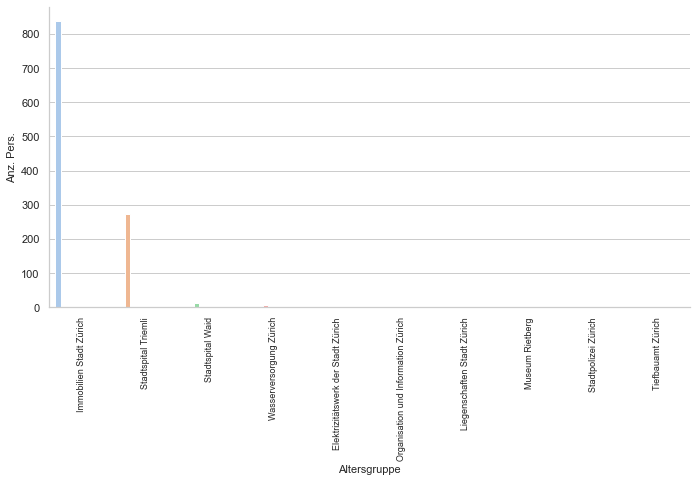

In [73]:
#sns.color_palette("flare", as_cmap=True)
myHist = sns.catplot(x="verantwortliche_da"
            , y="sum_anzahl_kameras_aussen"
            , hue="verantwortliche_da"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="pastel" #, color="green"
            , height=5
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.reset_index().sort_values('sum_anzahl_kameras_aussen', ascending=False) 
           )
myHist.set_xticklabels(rotation=90, fontsize=9) 
myHist.set_xlabels('Altersgruppe', fontsize=11) # not set_label
myHist.set_ylabels('Anz. Pers.', fontsize=11)


In [74]:
#data2betested.columns

In [75]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested\
    .groupby(['verantwortliche_da','aufbewahrungsdauer']) \
    .agg(sum_anzahl_kameras_gsa=('anzahl_kameras_gsa', 'sum')
         ,sum_anzahl_kameras_aussen=('anzahl_kameras_aussen', 'sum')
         ,sum_anzahl_kameras_innen=('anzahl_kameras_innen', 'sum')) \
    .sort_values('sum_anzahl_kameras_gsa', ascending=False) 

myAggBar.reset_index().head(3)

,verantwortliche_da,aufbewahrungsdauer,sum_anzahl_kameras_gsa,sum_anzahl_kameras_aussen,sum_anzahl_kameras_innen
0,Immobilien Stadt Zürich,20,27,22,243
1,Elektrizitätswerk der Stadt Zürich,15,0,2,0
2,Immobilien Stadt Zürich,7,0,816,0


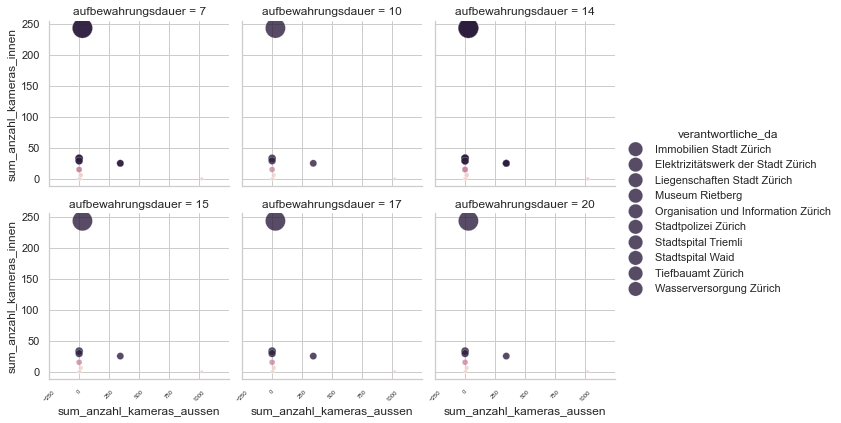

In [76]:
#g = sns.FacetGrid(myAggBar.reset_index(), col="QuarLang", hue="HerkunftLang", col_wrap=6, height=3,)
#g.map(sns.scatterplot, "AlterV05Sort", "sum_WBev", alpha=.8)
#g.add_legend()

g2 = sns.FacetGrid(myAggBar.reset_index(), col="aufbewahrungsdauer", hue="verantwortliche_da", col_wrap=3, height=3,)
g2.map(sns.scatterplot
       , data=myAggBar.reset_index()
       ,x="sum_anzahl_kameras_aussen"
       ,y="sum_anzahl_kameras_innen"
       ,alpha=.8
       ,hue="sum_anzahl_kameras_innen"
       , size="sum_anzahl_kameras_innen"
       , sizes=(10, 400), hue_norm=(10,25), legend="full"
      )

g2.set_xticklabels(rotation=45, fontsize=6) 
g2.add_legend()



### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

#### Aktueller Bestand der WBev nach Quartier, Herkunft und Geschlecht

In [77]:
data2betested.columns

Index(['standort_beschreibung', 'adresse_beschreibung', 'lat', 'lon', 'anzahl_kameras_aussen',
       'anzahl_kameras_innen', 'anzahl_kameras_gsa', 'bereich_detail_beschreibung',
       'aufbewahrungsdauer', 'verantwortliche_da', 'rechtsgrundlage_url'],
      dtype='object')

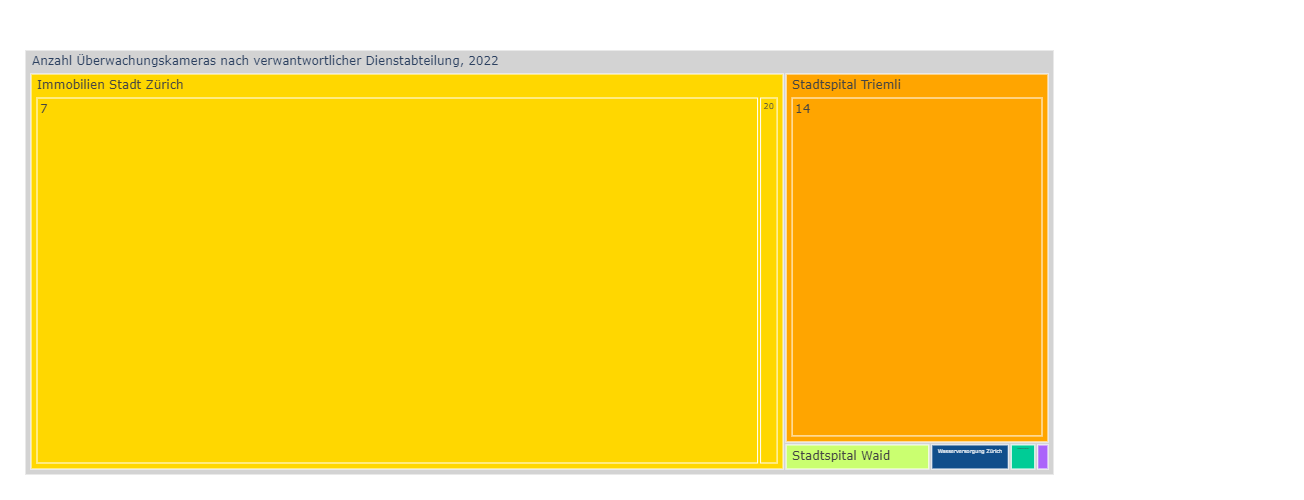

In [78]:
myTitle = "Anzahl Überwachungskameras nach verwantwortlicher Dienstabteilung, 2022"

fig = px.treemap(data2betested.query('anzahl_kameras_aussen > 0').reset_index(), path=[px.Constant(myTitle), 'verantwortliche_da', 'aufbewahrungsdauer']
                 , values='anzahl_kameras_aussen'
                 , color='verantwortliche_da'
                 ## bei discrete scales (bei Klassen und Strings):                 
                 , color_discrete_map={'(?)':'lightgrey','Immobilien Stadt Zürich':'gold', 'SP':'#FF3030', 'PdA':'#EE3B3B', 'Grüne':'#A2CD5A','Stadtspital Waid':'#CAFF70','Stadtspital Triemli':'orange','Wasserversorgung Zürich':'#104E8B','AL':'deeppink','SVP':'forestgreen', 'FL ZÜRI':'#8B864E','Volt':'#lightblue' }                
                 ## bei continuous scales (bei Zahlenwerten):
                , color_continuous_scale='Blues'
                #, color_continuous_midpoint=np.average(df['AnzBestWir'], weights=df['AnzBestWir'])  
                 ,height=500
                 ,width=1100                 
                )
fig.update_traces(root_color="grey")
fig.update_layout(margin = dict(t=50, l=25, r=250, b=25))
fig.show()

### Teste LeafMap

Mehr Infos: https://leafmap.org/leafmap/

In [109]:
data2betested.columns

Index(['standort_beschreibung', 'adresse_beschreibung', 'lat', 'lon', 'anzahl_kameras_aussen',
       'anzahl_kameras_innen', 'anzahl_kameras_gsa', 'bereich_detail_beschreibung',
       'aufbewahrungsdauer', 'verantwortliche_da', 'rechtsgrundlage_url', 'geometry'],
      dtype='object')

**Generiere einen Geodataframe aus den importierten Daten**

In [181]:
gdf_data2betested = gpd.GeoDataFrame(
    data2betested, geometry=gpd.points_from_xy(x=data2betested.lon, y=data2betested.lat)
)

gdf_data2betested=gdf_data2betested.set_crs(epsg=4326)

#print(gdf_data2betested.crs)
#to_crs(crs=crs, epsg=2020)
gdf_data2betested.head(2)


,standort_beschreibung,adresse_beschreibung,lat,lon,anzahl_kameras_aussen,anzahl_kameras_innen,anzahl_kameras_gsa,bereich_detail_beschreibung,aufbewahrungsdauer,verantwortliche_da,rechtsgrundlage_url,geometry
7,Grundwasserwerk Hardhof,"Hardhof 9, 8064 Zürich, Switzerland",47,8,3,0,0,gem. 236.871 Reglement Videoüberwachung Wasser...,10,Wasserversorgung Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...,POINT (8.49626 47.39788)
8,Seewasserwerk Lengg,"Enzenbühlstrasse 21, 8008 Zürich, Switzerland",47,9,2,0,0,gem. 236.871 Reglement Videoüberwachung Wasser...,10,Wasserversorgung Zürich,https://www.stadt-zuerich.ch/portal/de/index/p...,POINT (8.57227 47.34951)


#### Version 1: add_gdf()-Methode

Siehe dazu: https://leafmap.org/leafmap/#leafmap.leafmap.Map.add_gdf

In [182]:
import leafmap

m = leafmap.Map()
m.add_gdf(gdf_data2betested, style={}, hover_style={}, style_callback=None, fill_colors=['black'], info_mode='on_click', zoom_to_layer=True, encoding='utf-8')

m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

#### Version 2: add_points_from_xy()-Methode

Siehe dazu: https://leafmap.org/leafmap/#leafmap.leafmap.Map.add_points_from_xy

In [186]:
popup_list=["verantwortliche_da","standort_beschreibung","adresse_beschreibung","anzahl_kameras_aussen", "anzahl_kameras_innen"]
#popup_list=None
    
m = leafmap.Map()
m.add_points_from_xy(gdf_data2betested, x="lon", y="lat"
                     , popup=popup_list
                     , layer_name='Marker Cluster'
                     , color_column=["verantwortliche_da"]
                     , marker_colors=["verantwortliche_da"]
                     , icon_colors=['pink']
                     , icon_names=['circle'], spin=True
                     , add_legend=True
                    )
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

Als HTML-Seite exportieren:

In [188]:
#m.to_html("mymap.html")

## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=115&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

#### Stadtkreise

In [94]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
geojson_url_kreise = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Stadtkreise?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_stadtkreise_v"
adm_stadtkreise_v = gpd.read_file(geojson_url_kreise)

adm_stadtkreise_v.head(1)


,id,kname,knr,objid,geometry
0,adm_stadtkreise_v.6,Kreis 7,7,6,"POLYGON ((8.54885 47.36602, 8.54901 47.36601, ..."
